In [3]:
import numpy as np
import matplotlib.pyplot as plt
import time
import torch
import torch.nn as nn
import tqdm
from scipy.interpolate import griddata

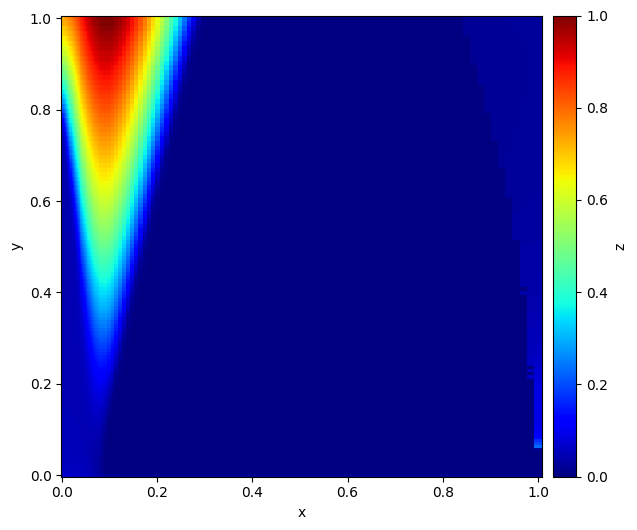

In [5]:
data = np.loadtxt("D_turbulent_jet.txt")
x, y, z = data[:, 0], data[:, 1], data[:, 2]

# уникальные узлы исходной сетки
xi = np.unique(np.round(x, 12))
yi = np.unique(np.round(y, 12))
X, Y = np.meshgrid(xi, yi)

# перенос нерегулярно записанных точек на прямоугольную сетку
Z = griddata(np.column_stack([x, y]), z, (X, Y), method="nearest")
Z = np.nan_to_num(Z, nan=0.0)
# --- нормализация ---
z_ref = np.max(Z)
Zn = Z / z_ref
vmin, vmax = 0.0, Zn.max()
x_ref = np.max(X)
Xn=X/x_ref
vmin, vmax=0.0, Xn.max()
y_ref=np.max(Y)
Yn=Y/y_ref
vmin, vmax = 0.0,Yn.max()
# 1. Двумерная карта в стиле снимка
fig, ax = plt.subplots(figsize=(6.6, 5.4))

pcm = ax.pcolormesh(
    Xn, Yn, Zn,
    cmap="jet",
    shading="auto",
    vmin=0,

)



cb = fig.colorbar(pcm, ax=ax, pad=0.02)
cb.set_label("z")

ax.set_xlabel("x")
ax.set_ylabel("y")
#ax.set_xlim(xi.min(), xi.max())
#ax.set_ylim(yi.min(), yi.max())
ax.set_aspect("auto")
fig.tight_layout()
plt.show()



In [6]:
class PINNModel(nn.Module):
    def __init__(
        self,
        input_size=2,
        nnodes=5,
        output_size=1,
        nhlayers=3,
        activation=nn.Tanh(),
    ):
        super().__init__()
        self.activation = activation
        self.nhlayers = nhlayers
        self.nnodes = nnodes

        self.dense0 = nn.Linear(input_size, nnodes)
        self.hidden_layers = nn.ModuleList(
            [nn.Linear(nnodes, nnodes) for _ in range(nhlayers)]
        )
        self.output_layer = nn.Linear(nnodes, output_size)

    def forward(self, x):
        if x.dtype == torch.float64:
            x = x.float()
        x = self.activation(self.dense0(x))
        for layer in self.hidden_layers:
            x = self.activation(layer(x))
        x = self.output_layer(x)
        x = self.activation(x)
        return x

model = PINNModel(input_size=2, nnodes=5, output_size=1, nhlayers=3, activation=nn.Tanh())
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"Число обучаемых параметров: {n_params}")

PINNModel(
  (activation): Tanh()
  (dense0): Linear(in_features=2, out_features=5, bias=True)
  (hidden_layers): ModuleList(
    (0-2): 3 x Linear(in_features=5, out_features=5, bias=True)
  )
  (output_layer): Linear(in_features=5, out_features=1, bias=True)
)
Число обучаемых параметров: 111


In [7]:
x_rand = torch.randn(8, 2)
y_rand = model(x_rand)
print("Вход:", tuple(x_rand.shape), x_rand.dtype)
print("Выход:", tuple(y_rand.shape), y_rand.dtype)
print(y_rand.detach().numpy().ravel())
assert y_rand.shape == (8, 1)
assert torch.all(y_rand > -1) and torch.all(y_rand < 1)
print("Проверка пройдена: форма (N, 1), значения в (-1, 1).")

Вход: (8, 2) torch.float32
Выход: (8, 1) torch.float32
[-0.3672796  -0.34791014 -0.48945582 -0.36507073 -0.39208382 -0.46713978
 -0.45199576 -0.2658677 ]
Проверка пройдена: форма (N, 1), значения в (-1, 1).


In [8]:
xy_np = np.column_stack([Xn.flatten(), Yn.flatten()]).astype(np.float32)
z_np = Zn.flatten()[:, None].astype(np.float32)

xy_train = torch.from_numpy(xy_np)
z_train = torch.from_numpy(z_np)

print("xy_train:", tuple(xy_train.shape), xy_train.dtype)
print("z_train:", tuple(z_train.shape), z_train.dtype)

xy_train: (14641, 2) torch.float32
z_train: (14641, 1) torch.float32


In [9]:
class TrainParams:
    def __init__(self, numEpoch=80, xy=None, z=None):
        self.numEpoch = numEpoch
        self.xy = xy
        self.z = z


def copyLoss(model, trp):
    pred = model(trp.xy)
    return torch.mean((pred - trp.z) ** 2)


def train(model, opt, trp):
    hist_loss = []
    pbar = tqdm.tqdm(range(trp.numEpoch), desc="Training Progress")
    t0 = time.time()
    for step in pbar:

        def closure():
            opt.zero_grad()
            loss = copyLoss(model, trp)
            loss.backward()
            return loss

        current_loss = float(opt.step(closure).detach())
        hist_loss.append(current_loss)
        if step % 2 == 0:
            pbar.set_description("Step: %d | Loss: %.10f" % (step, current_loss))

    torch.save(model.state_dict(), "pinn_model")
    print(f"Обучение заняло {time.time() - t0:.1f} с. Веса сохранены в 'pinn_model'.")
    return hist_loss


trp = TrainParams(numEpoch=80, xy=xy_train, z=z_train)
opt = torch.optim.LBFGS(
    model.parameters(),
    lr=1.0,
    max_iter=20,
    history_size=50,
    line_search_fn="strong_wolfe",
)
hist_loss = train(model, opt, trp)
print(f"Итоговый Loss = {hist_loss[-1]:.6e}")

Step: 78 | Loss: 0.0000898643: 100%|██████████| 80/80 [00:12<00:00,  6.16it/s]

Обучение заняло 13.0 с. Веса сохранены в 'pinn_model'.
Итоговый Loss = 8.861276e-05


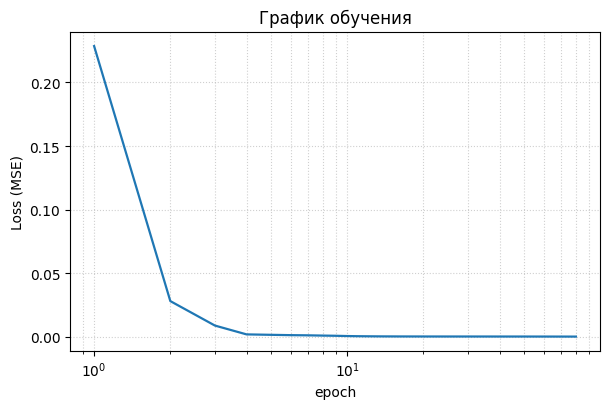

In [10]:
fig, ax = plt.subplots(figsize=(6.2, 4.2))
ax.plot(np.arange(1, len(hist_loss) + 1), hist_loss, color="tab:blue", lw=1.6)
ax.set_xscale("log")
ax.set_xlabel("epoch")
ax.set_ylabel("Loss (MSE)")
ax.set_title("График обучения")
ax.grid(True, which="both", ls=":", alpha=0.6)
fig.tight_layout()
plt.show()

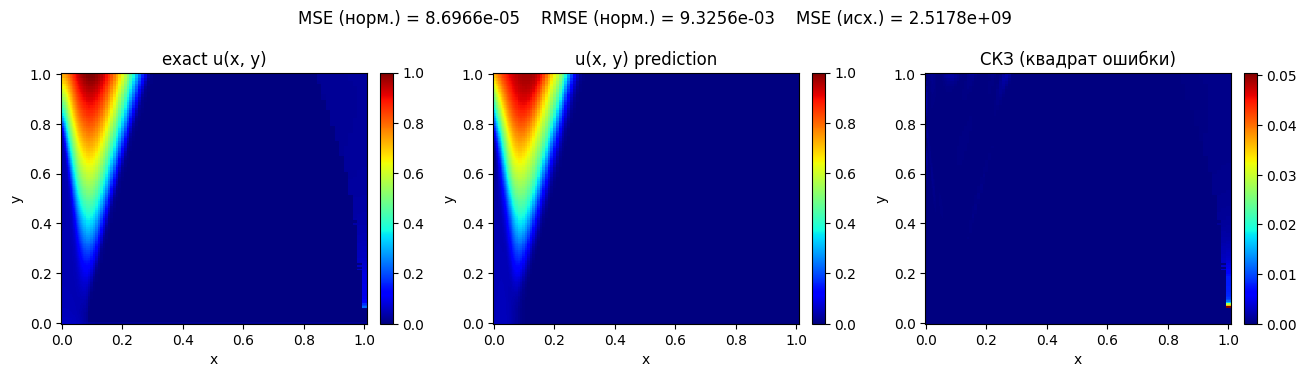

MSE в нормированных переменных : 8.696627e-05
RMSE в нормированных переменных: 9.325571e-03
MSE в исходных единицах        : 2.517796e+09


In [13]:
model.eval()
with torch.no_grad():
    z_pred_n = model(xy_train).cpu().numpy().reshape(Zn.shape)

err2 = (z_pred_n - Zn) ** 2
mse_norm = float(np.mean(err2))
rmse_norm = float(np.sqrt(mse_norm))

z_pred = z_pred_n*z_ref
mse_orig = float(np.mean((z_pred - Z) ** 2))

fig, axes = plt.subplots(1, 3, figsize=(13.2, 3.8))

im0 = axes[0].pcolormesh(Xn, Yn, Zn, cmap="jet", shading="auto", vmin=0, vmax=1)
axes[0].set_title("exact u(x, y)")
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].pcolormesh(Xn, Yn, z_pred_n, cmap="jet", shading="auto", vmin=0, vmax=1)
axes[1].set_title("u(x, y) prediction")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

im2 = axes[2].pcolormesh(Xn, Yn, err2, cmap="jet", shading="auto")
axes[2].set_title("СКЗ (квадрат ошибки)")
fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

for ax in axes:
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect("auto")

fig.suptitle(f"MSE (норм.) = {mse_norm:.4e}    RMSE (норм.) = {rmse_norm:.4e}    MSE (исх.) = {mse_orig:.4e}")
fig.tight_layout()
plt.show()

print(f"MSE в нормированных переменных : {mse_norm:.6e}")
print(f"RMSE в нормированных переменных: {rmse_norm:.6e}")
print(f"MSE в исходных единицах        : {mse_orig:.6e}")